# Analysis of Body Measurements (NHANES Dataset)




## Domain: Data Science
### Nandini Sethiya

---




## 1. Introduction

This report presents an analysis of body measurement data obtained from the National Health and Nutrition Examination Survey (NHANES). The dataset contains measurements for adult male and female participants, including weight, standing height, upper arm length, upper leg length, arm circumference, hip circumference, and waist circumference.

The objective of this analysis is to compare the body measurements of male and female participants using statistical methods and data visualizations. Additional health-related measures, including Body Mass Index (BMI), waist-to-height ratio, and waist-to-hip ratio, are also calculated to provide further insights into the dataset. Correlation analysis and standardized measurements are used to examine the relationships between different body measurements and identify meaningful patterns.

The findings presented in this report aim to provide a clear understanding of the characteristics of the dataset through descriptive statistics, graphical analysis, and interpretation of the results.

In [ ]:
#Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import seaborn as sns


## 2. Data Loading

The male and female datasets were loaded from CSV files into NumPy matrices. Header rows and metadata comments present in the source files were excluded during import.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
female=np.genfromtxt("/content/drive/MyDrive/capstone_project/nhanes_adult_female_bmx_2020.csv", delimiter=",", comments="#",skip_header=19)
female.shape

(4221, 7)

In [ ]:
male=np.genfromtxt("/content/drive/MyDrive/capstone_project/nhanes_adult_male_bmx_2020.csv", delimiter=",", comments="#",skip_header=19)
male.shape

(4081, 7)

In [ ]:

np.isnan(female).sum(),np.isnan(male).sum()

(np.int64(0), np.int64(0))

Both datasets were successfully loaded as NumPy matrices. The female dataset contains 4221 observations and the male dataset contains 4081 observations, each with 7 body measurement variables: weight, standing height, upper arm length, upper leg length, arm circumference, hip circumference and waist circumference. After the data is loaded both matrices were verified to contain no missing values.

## 3. Body Weight Distribution

To compare how body weight is distributed between male and female participants, histograms of both groups were plotted on a shared horizontal scale, allowing direct visual comparison of their distributions.

In [ ]:
female_weight = female[:,0]
male_weight = male[:,0]

In [ ]:
# Calculate shared x-axis limits so both histograms use the same scale
min_weight = min(female_weight.min(),male_weight.min())
max_weight = max(female_weight.max(),male_weight.max())
print(min_weight, max_weight)

32.6 204.6


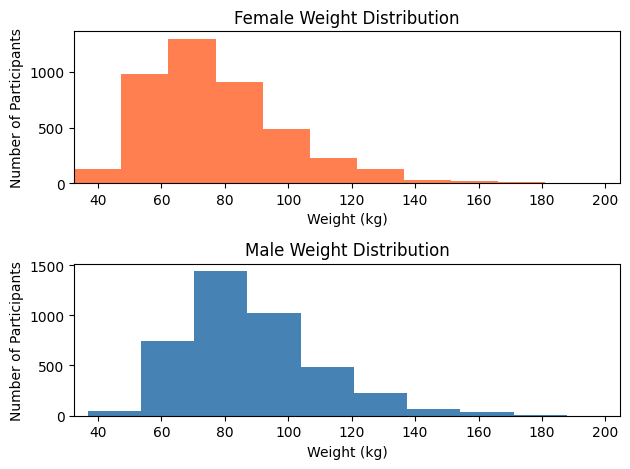

In [ ]:
plt.subplot(2, 1, 1)
plt.hist(female_weight, color="coral")
plt.xlim(min_weight, max_weight)
plt.title("Female Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Number of Participants")

plt.subplot(2,1,2)
plt.hist(male_weight, color="steelblue")
plt.xlim(min_weight,max_weight)
plt.title("Male Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Number of Participants")

plt.tight_layout()
plt.show()

Both distributions show a right-skewed pattern, with the majority of participants concentrated in lower-to-middle weight range. The female weight distribution appears to peak between 65-75kg, while the male distribution peaks slightly higher, around 70-85kg suggesting that male participants tend to have higher average weight than the female participants. The male distribution also appears to have a taller peak and a wider spread toward higher weights, indicating greater variability among male participants in this sample.

## 4. Male vs Female Weight : Box Plot Comparison

To compare weight between the two groups more clearly, a boxplot was created showing male and female weight side by side. This type of plot makes it easy to see the typical weight, how spread out the values are, and whether there are any unusual (outlier) values in each group.

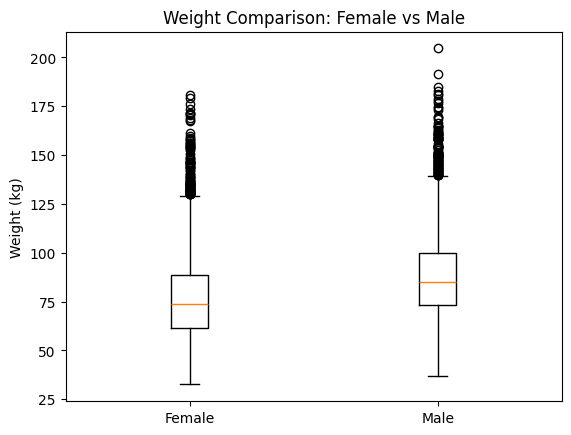

In [ ]:
plt.boxplot([female_weight,male_weight],tick_labels=["Female","Male"])
plt.ylabel("Weight (kg)")
plt.title("Weight Comparison: Female vs Male")
plt.show()

The orange line in the boxplot represents the median. The female median sits around 73-74 kg, while the male median is approximately 85 kg, indicating that male participants typically weigh more than female participants. The male group also shows greater variability, with a slightly higher upper whisker compared to females. Both groups contain several outliers on the high end, consistent with the right-skewed distributions observed earlier; the most extreme male outlier reaches approximately 204 kg, compared to around 180 kg for females.

## 5. Summary Statistics: Male vs Female Weight

To further quantify the differences observed in the histograms and boxplot, numerical summary statistics were computed for both groups, covering measures of location, dispersion, and shape.

In [ ]:
print("Female Weight Statistics")
print("Mean:", np.mean(female_weight).round(2))
print("Median:", np.median(female_weight).round(2))
print("Std Dev:", np.std(female_weight).round(2))
print("Skewness:", stats.skew(female_weight).round(2))

print() #for spacing

print("Male Weight Statistics")
print("Mean:", np.mean(male_weight).round(2))
print("Median:", np.median(male_weight).round(2))
print("Std Dev:", np.std(male_weight).round(2))
print("Skewness:", stats.skew(male_weight).round(2))

Female Weight Statistics
Mean: 77.4
Median: 73.6
Std Dev: 21.54
Skewness: 1.03

Male Weight Statistics
Mean: 88.36
Median: 85.0
Std Dev: 21.42
Skewness: 0.98


Male participants have a higher average weight than female participants, by approximately 11 kg. The skewness values for both groups i.e. 0.98 for males and 1.03 for females are positive and similar in magnitude, confirming that both distributions are right-skewed, consistent with what was observed in the histogram and boxplot.

The standard deviations of the two groups are also very close, indicating similar overall spread. This suggests that the slightly higher whisker seen in the boxplot reflects only a minor difference at the upper end, rather than a meaningfully wider spread across the whole distribution.

## 6. Adding a BMI Column to the Female Dataset

Body Mass Index (BMI) was calculated for each female participant using their weight (kg) and height (m), and the resulting values were added as a new column to the female dataset. This provides an additional standard measure of body composition for later comparison and analysis.

In [ ]:
# Convert height from cm to m, then calculate BMI
female_height_m = female[:,1] / 100
female_bmi = female_weight / (female_height_m**2)

#Adding new column BMI to female dataset
female = np.column_stack((female,female_bmi))
female.shape

(4221, 8)

In [ ]:
#Minimum and Maximum values of BMI calculated
female_bmi.min().round(2), female_bmi.max().round(2)

(np.float64(14.2), np.float64(67.04))

Following this step, the female dataset now contains eight columns, with the additional column representing each participant's BMI, calculated from their weight and height. The calculated BMI values range from approximately 14.2 to 67.0, reflecting the wide variation in body composition across the sample, from underweight to severely obese individuals. This new variable will be used in later sections of the analysis, including standardization and comparison with other body measurements.


## 7. Standardizing the Female Dataset

To allow fair comparison between variables measured on different scales, the female dataset was standardized by converting each column into z-scores, producing a new matrix called zfemale.

In [ ]:
column_means = np.mean(female, axis=0)
column_stds = np.std(female, axis=0)
zfemale = (female - column_means) / column_stds
zfemale.shape
zfemale[:5].round(2)

array([[ 0.91,  0.01, -0.57,  1.13,  0.55,  1.08,  1.12,  1.  ],
       [ 0.64, -1.05, -1.08, -1.29,  1.03,  1.04,  0.27,  1.16],
       [-0.2 ,  0.15,  0.58,  0.26, -0.16, -0.19, -0.37, -0.26],
       [-0.73, -0.39,  0.84, -0.76, -0.66, -0.52, -0.46, -0.67],
       [-1.02, -0.78, -0.61, -0.98, -0.79, -1.07, -1.45, -0.89]])

In [ ]:
#Verification of mean
np.mean(zfemale, axis=0).round(2)

array([ 0.,  0., -0., -0.,  0., -0.,  0., -0.])

In [ ]:
#Verification of std deviation
np.std(zfemale, axis=0).round(2)

array([1., 1., 1., 1., 1., 1., 1., 1.])

zfemale is a standardized version of the female dataset. It was created by computing the mean and standard deviation of each column and using these to calculate the corresponding z-scores. The verification step confirms that every column in zfemale now has a mean of approximately 0 and a standard deviation of 1, indicating that the standardization was performed correctly and that all variables are now on a comparable scale.

## 8. Relationships Between Standardized Variables

To examine relationships between key body measurements, a scatterplot matrix was constructed using the standardized height, weight, waist circumference, hip circumference, and BMI of the females (based on zfemale). Pearson's and Spearman's correlation coefficients were also computed for each pair of variables to quantify the strength and direction of these relationships.

In [ ]:
columns = [1, 0, 6, 5, 7]
labels = ["Height", "Weight", "Waist", "Hip", "BMI"]
selected = zfemale[:, columns]

df = pd.DataFrame(selected, columns=labels)
df.head()

,Height,Weight,Waist,Hip,BMI
0,0.008950,0.914295,1.115785,1.083162,0.996968
1,-1.053068,0.635776,0.265089,1.044755,1.156175
2,0.150553,-0.204423,-0.372933,-0.190647,-0.259275
3,-0.387537,-0.728968,-0.459152,-0.523501,-0.670391
4,-0.784024,-1.021413,-1.453546,-1.067590,-0.892899


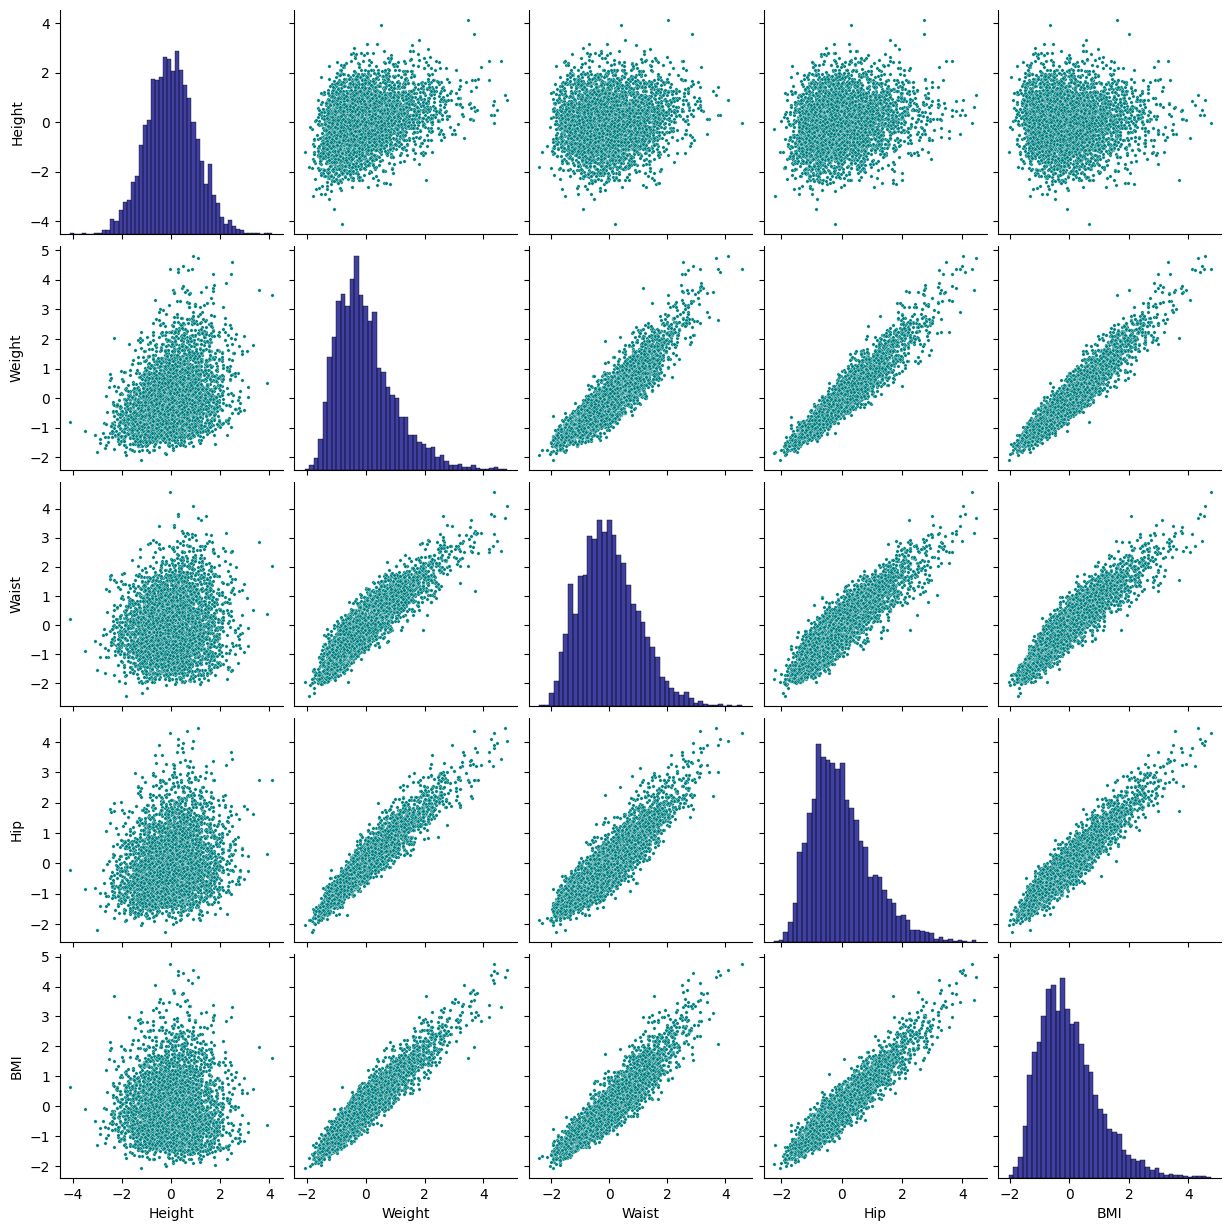

In [ ]:
sns.pairplot(df,plot_kws={"color": "teal", "s":6}, diag_kws={"color": "navy"})
plt.show()

In [ ]:
pearson_corr = df.corr(method="pearson")
spearman_corr = df.corr(method="spearman")

print("Pearson Correlation Matrix")
print(pearson_corr.round(2))

print("\nSpearman Correlation Matrix")
print(spearman_corr.round(2))

Pearson Correlation Matrix
        Height  Weight  Waist   Hip   BMI
Height    1.00    0.35   0.13  0.20  0.03
Weight    0.35    1.00   0.90  0.95  0.95
Waist     0.13    0.90   1.00  0.90  0.92
Hip       0.20    0.95   0.90  1.00  0.94
BMI       0.03    0.95   0.92  0.94  1.00

Spearman Correlation Matrix
        Height  Weight  Waist   Hip   BMI
Height    1.00    0.34   0.11  0.21  0.02
Weight    0.34    1.00   0.90  0.95  0.94
Waist     0.11    0.90   1.00  0.89  0.92
Hip       0.21    0.95   0.89  1.00  0.93
BMI       0.02    0.94   0.92  0.93  1.00


Height shows notably weak correlation with the other variables, especially BMI (Pearson and Spearman both near 0.02-0.03). This is expected, since BMI is calculated using height, so a near-zero correlation confirms it adjusts for height correctly.

Weight, waist, hip, and BMI are all strongly correlated with each other (0.89-0.95), showing that individuals with higher body weight also tend to have larger waist and hip measurements and higher BMI.

Pearson and Spearman values are nearly identical throughout, suggesting the relationships between these variables are approximately linear.

## 9. Calculating Waist-to-Height and Waist-to-Hip Ratios

Two new ratios: waist-to-height and waist-to-hip were calculated for both male and female participants and added as new columns to their datasets. These give extra ways to look at body shape, beyond just BMI.

In [ ]:
female_waist_height_ratio = female[:, 6] / female[:, 1]
female_waist_hip_ratio = female[:, 6] / female[:, 5]

female = np.column_stack((female, female_waist_height_ratio, female_waist_hip_ratio))
female.shape

(4221, 10)

In [ ]:
male_waist_height_ratio = male[:, 6] / male[:, 1]
male_waist_hip_ratio = male[:, 6] / male[:, 5]

male = np.column_stack((male, male_waist_height_ratio, male_waist_hip_ratio))
male.shape

(4081, 9)

In [ ]:
print("Female waist-to-height ratio range:", female_waist_height_ratio.min().round(2), "-", female_waist_height_ratio.max().round(2))
print("Female waist-to-hip ratio range:", female_waist_hip_ratio.min().round(2), "-", female_waist_hip_ratio.max().round(2))
print("Male waist-to-height ratio range:", male_waist_height_ratio.min().round(2), "-", male_waist_height_ratio.max().round(2))
print("Male waist-to-hip ratio range:", male_waist_hip_ratio.min().round(2), "-", male_waist_hip_ratio.max().round(2))

Female waist-to-height ratio range: 0.38 - 1.11
Female waist-to-hip ratio range: 0.66 - 1.17
Male waist-to-height ratio range: 0.37 - 0.97
Male waist-to-hip ratio range: 0.73 - 1.24


Following this step, the female dataset now contains 10 columns and the male dataset contains 9 columns, reflecting the addition of the waist-to-height and waist-to-hip ratio columns. The waist-to-height ratio ranged from approximately 0.37 to 1.11 across both groups, while the waist-to-hip ratio ranged from approximately 0.66 to 1.24. These values are broadly reasonable for an adult population that includes a wide range of body sizes, including some individuals at the higher end of the obesity spectrum.

## 10. Comparing Waist-to-Height and Waist-to-Hip Ratios by Sex

A boxplot with four boxes was created to compare the waist-to-height and waist-to-hip ratios between male and female participants, allowing all four distributions to be examined side by side.

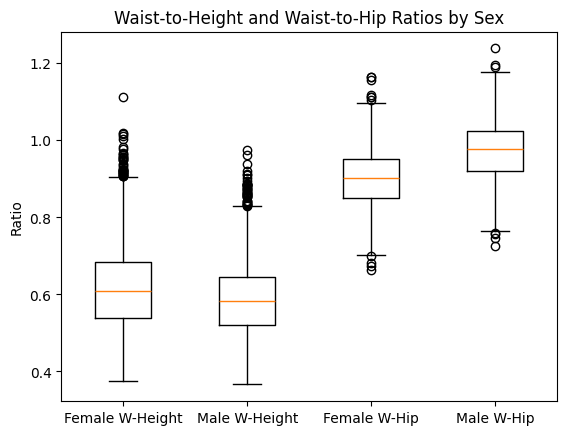

In [ ]:
plt.boxplot(
    [female_waist_height_ratio, male_waist_height_ratio, female_waist_hip_ratio, male_waist_hip_ratio],
    tick_labels=["Female W-Height", "Male W-Height", "Female W-Hip", "Male W-Hip"]
)
plt.ylabel("Ratio")
plt.title("Waist-to-Height and Waist-to-Hip Ratios by Sex")
plt.show()

The waist-to-height ratio is similar between males and females, with comparable medians and spread, indicating little difference between the sexes on this measure. In contrast, the waist-to-hip ratio shows a clearer gap, with males having a noticeably higher median than females. This is likely explained biologically: males tend to carry more abdominal or visceral fat relative to hip size, whereas females typically have proportionally larger hip circumference, resulting in a lower waist-to-hip ratio. Additionally, the waist-to-hip ratio shows outliers on both the lower and upper ends, unlike the waist-to-height ratio, where outliers appear mainly at the higher end.

## 11. Advantages and Disadvantages of BMI, Waist-to-Height Ratio, and Waist-to-Hip Ratio

**BMI:**

Advantages-

*  Simple to calculate, requiring only weight and height.
*  Widely used and well understood, making it easy to compare across studies and populations.

Disadvantages-

*  Does not distinguish muscle from fat, so a muscular person may appear overweight despite low body fat.
*  Does not indicate where fat is distributed on the body, which matters for assessing health risk.

**Waist-to-Height Ratio:**

Advantages-

*  Captures abdominal fat more directly than BMI, which is more strongly linked to health risks such as heart disease.
*  Adjusts for a person's height, similar to BMI, while focusing specifically on fat location.

Disadvantages-

*  Waist measurements are prone to inconsistency, depending on tape placement and timing relative to meals.
*  Less standardized cutoff values compared to BMI.

**Waist-to-Hip Ratio:**

Advantages-

*  Distinguishes "apple-shaped" from "pear-shaped" fat distribution, offering insight BMI cannot provide.
*  Useful indicator of cardiovascular and metabolic risk independent of overall body size.

Disadvantages:

*  Requires two separate circumference measurements, increasing the chance of measurement error.
*  Less commonly used and understood than BMI, making comparisons across sources harder.

## 12. Standardized Measurements for Extreme BMI Cases

To examine how extreme BMI values relate to other standardized body measurements, the standardized measurements for the five female participants with the lowest BMI and the five with the highest BMI were identified and printed for comparison.

In [ ]:
bmi_order = np.argsort(zfemale[:, 7])
lowest_5 = bmi_order[:5]
highest_5 = bmi_order[-5:]

print("5 Lowest BMI participants (standardized measurements):")
print(zfemale[lowest_5].round(2))

print("\n5 Highest BMI participants (standardized measurements):")
print(zfemale[highest_5].round(2))

5 Lowest BMI participants (standardized measurements):
[[-2.08 -1.22 -1.55 -1.17 -2.19 -2.04 -1.94 -2.05]
 [-1.88 -0.19 -1.72  0.39 -2.44 -1.85 -2.06 -1.99]
 [-1.54  1.81  0.63  0.57 -2.27 -1.68 -1.71 -1.97]
 [-1.84 -0.26 -0.23  0.51 -2.3  -2.25 -1.86 -1.94]
 [-1.61  0.89 -0.1   0.48 -2.21 -1.83 -1.71 -1.89]]

5 Highest BMI participants (standardized measurements):
[[ 4.25  0.29  1.86 -0.98  2.37  4.1   3.82  4.4 ]
 [ 4.46  0.5   1.69 -1.14  3.35  3.98  2.9   4.46]
 [ 4.35  0.28  2.84  1.94  4.37  3.92  3.75  4.51]
 [ 4.8   0.89  2.12  1.82  3.78  4.02  4.08  4.54]
 [ 4.36 -0.03 -0.06 -0.17  2.78  4.32  4.57  4.76]]


The five lowest-BMI participants show strongly negative values for weight, hip, and waist circumference (roughly -1.5 to -2.4), reflecting smaller body size overall. The five highest-BMI participants show the opposite; strongly positive values (roughly 2.4 to 4.8) across the same measurements.
However, height stays close to zero or mixed in both groups, showing no clear link to BMI.


## References

1. U.S. Centers for Disease Control and Prevention (CDC), National Center for Health Statistics. *National Health and Nutrition Examination Survey (NHANES), 2017-March 2020 Pre-pandemic Data — Body Measures*. Published May 2021. Available at: https://wwwn.cdc.gov/Nchs/Nhanes/2017-2018/P_BMX.htm

2. Gagolewski, M. *Teaching Data Repository*. Available at: https://github.com/gagolews/teaching-data